In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
# --- 1. Load Data ---

# Load dataset from stable source
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

print(f"Loading dataset from {url}...")
df = pd.read_csv(url, names=columns)

print("Data loaded successfully.")
print(f"Shape: {df.shape}")
display(df.head())

Loading dataset from https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv...
Data loaded successfully.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Replacing 0s with NaN in columns: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Missing values per column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


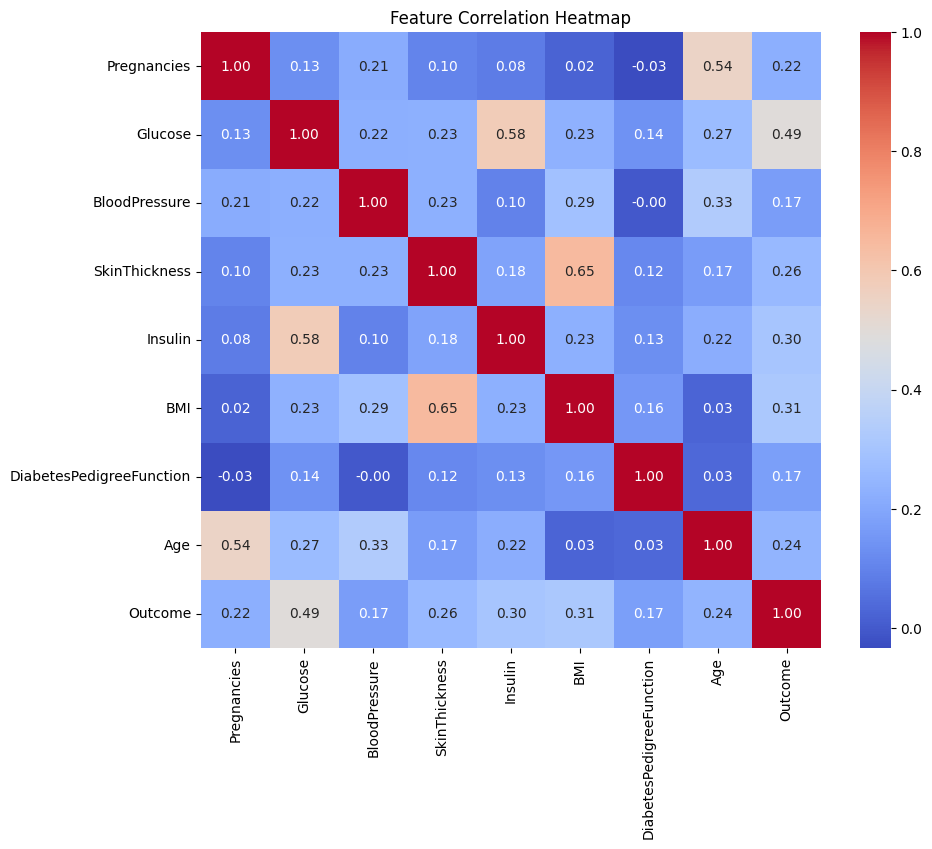

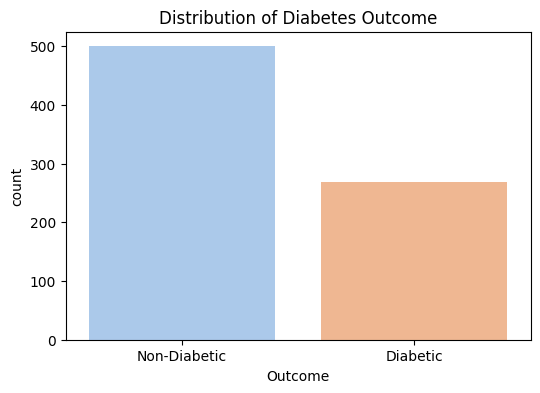

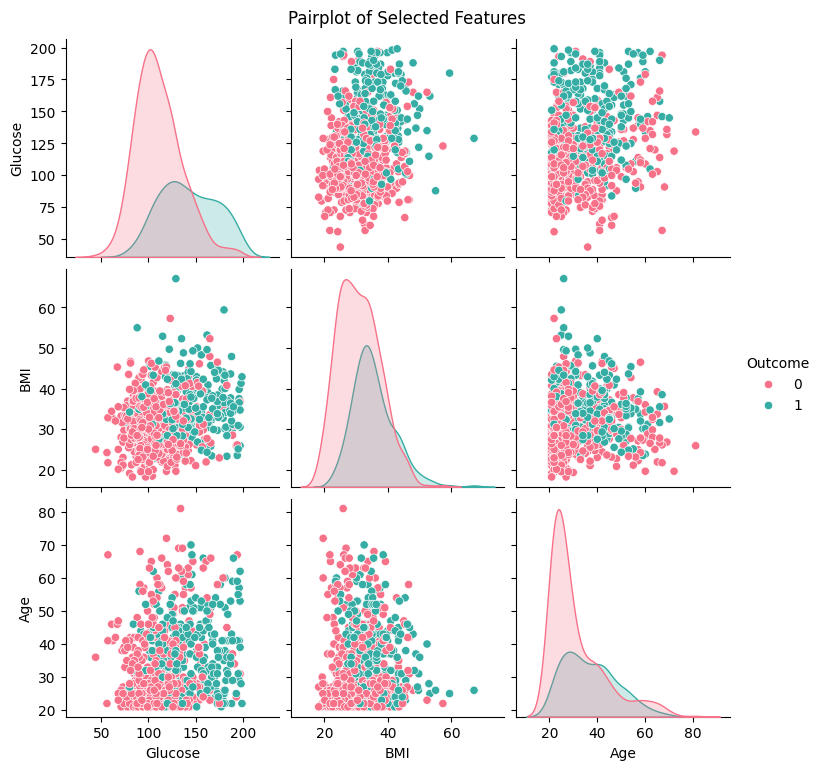

In [9]:
# --- 2. Preprocessing & EDA ---

# Handle missing values (0 treated as missing in medical fields)
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print(f"Replacing 0s with NaN in columns: {cols_with_zero}")
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# --- Visualizations ---

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Distribution of Outcome
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='pastel')
plt.title("Distribution of Diabetes Outcome")
plt.gca().set_xticklabels(['Non-Diabetic', 'Diabetic'])
plt.show()

# 3. Pairplot (visualize relationships)
# Use a subset of important features for clarity
subset_cols = ["Glucose", "BMI", "Age", "Outcome"]
sns.pairplot(df[subset_cols], hue="Outcome", palette="husl", diag_kind="kde")
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

In [10]:
# --- Imputation & Splitting ---

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# Impute missing values with median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_imputed, y, test_size=0.25, random_state=42, stratify=y
)

labels = {0: "Non-Diabetic", 1: "Diabetic"}
label_names = ["Non-Diabetic", "Diabetic"]
print(f"Training set: {X_tr.shape}")
print(f"Test set: {X_te.shape}")

Training set: (576, 8)
Test set: (192, 8)


Training Naive Bayes...
=== Naive Bayes ===
Accuracy: 0.7239583333333334

Classification Report:
               precision    recall  f1-score   support

Non-Diabetic       0.80      0.78      0.79       125
    Diabetic       0.60      0.63      0.61        67

    accuracy                           0.72       192
   macro avg       0.70      0.70      0.70       192
weighted avg       0.73      0.72      0.73       192



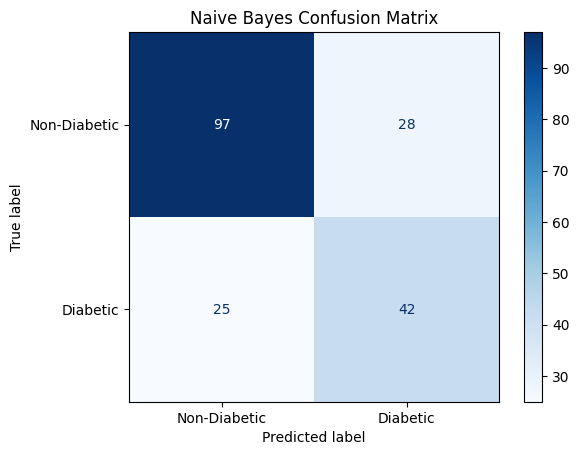

In [11]:
# --- 3. Model: Naive Bayes ---

print("Training Naive Bayes...")
nb = GaussianNB()
nb.fit(X_tr, y_tr)

y_pred_nb = nb.predict(X_te)
acc_nb = accuracy_score(y_te, y_pred_nb)

print("=== Naive Bayes ===")
print("Accuracy:", acc_nb)
print("\nClassification Report:\n",
      classification_report(y_te, y_pred_nb, target_names=label_names))

# Confusion Matrix Plot
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_nb, display_labels=label_names, cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Training Decision Tree...
=== Decision Tree (Entropy) ===
Accuracy: 0.7552083333333334

Classification Report:
               precision    recall  f1-score   support

Non-Diabetic       0.77      0.90      0.83       125
    Diabetic       0.72      0.49      0.58        67

    accuracy                           0.76       192
   macro avg       0.74      0.69      0.71       192
weighted avg       0.75      0.76      0.74       192



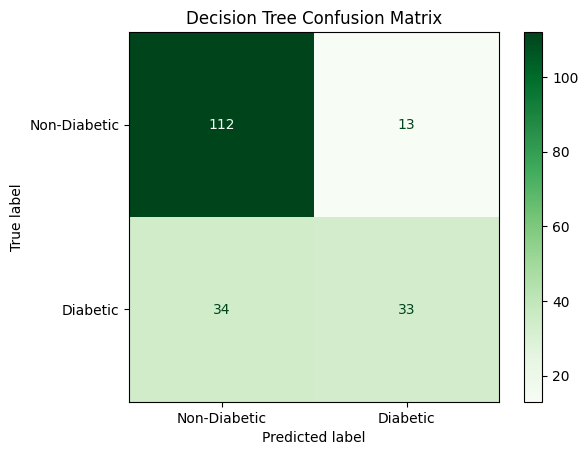

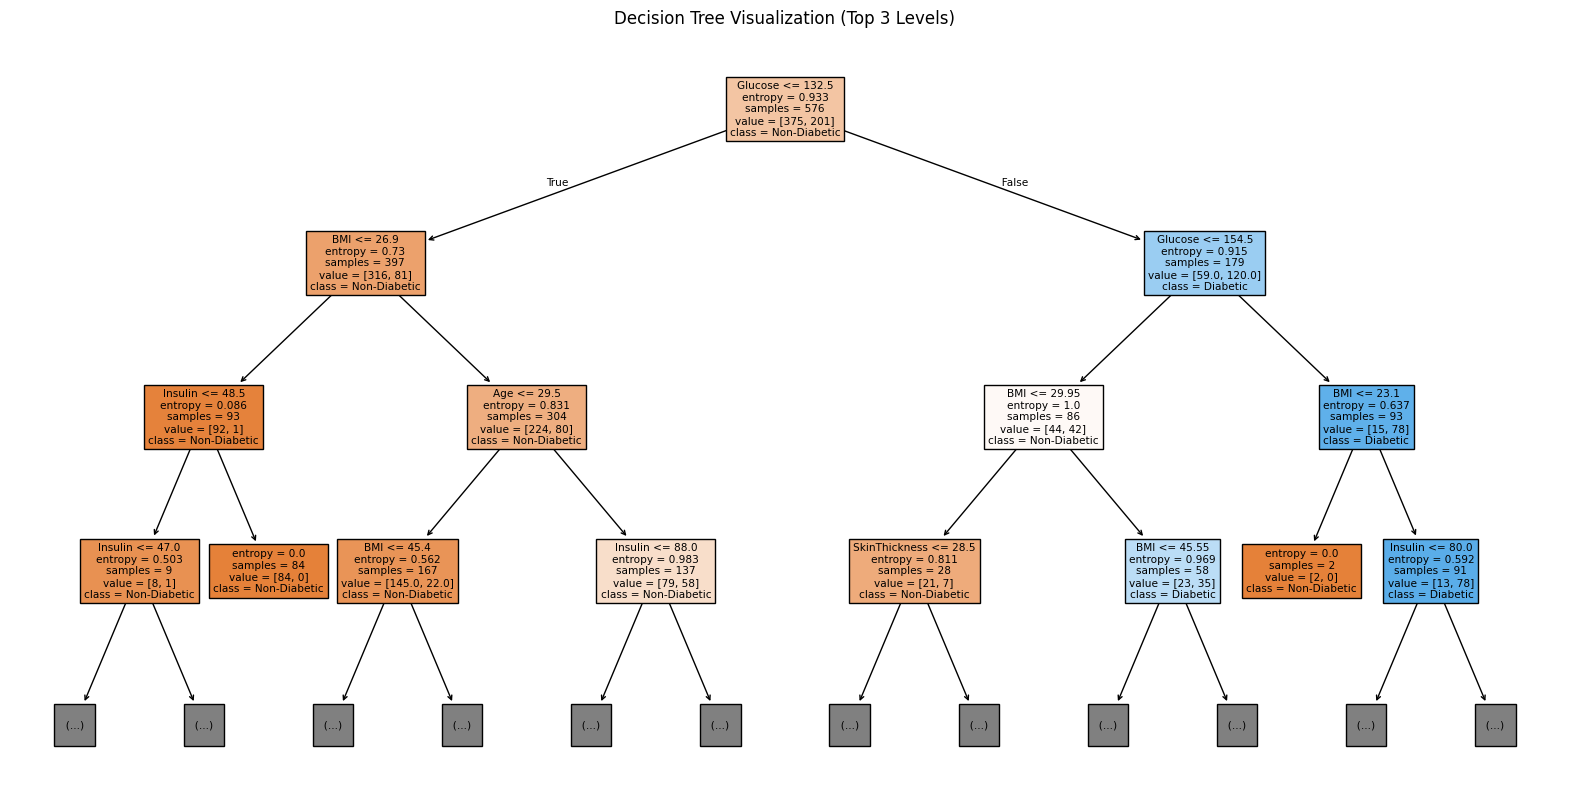

In [12]:
# --- 4. Model: Decision Tree ---

print("Training Decision Tree...")
dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,          # avoids overfitting
    random_state=42
)

dt.fit(X_tr, y_tr)
y_pred_dt = dt.predict(X_te)
acc_dt = accuracy_score(y_te, y_pred_dt)

print("=== Decision Tree (Entropy) ===")
print("Accuracy:", acc_dt)
print("\nClassification Report:\n",
      classification_report(y_te, y_pred_dt, target_names=label_names))

# Confusion Matrix Plot
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_dt, display_labels=label_names, cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Visualize Tree (optional)
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=columns[:-1], class_names=label_names, filled=True, max_depth=3)
plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.show()

Training MLP Classifier...
=== Artificial Neural Network (ANN) ===
Accuracy: 0.7135416666666666

Classification Report:
               precision    recall  f1-score   support

Non-Diabetic       0.78      0.78      0.78       125
    Diabetic       0.59      0.60      0.59        67

    accuracy                           0.71       192
   macro avg       0.69      0.69      0.69       192
weighted avg       0.71      0.71      0.71       192



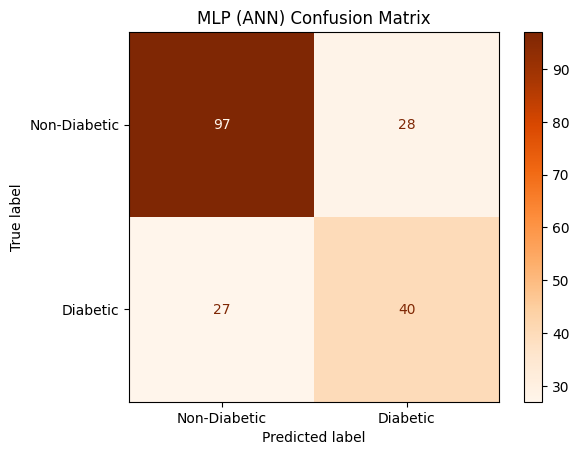

In [13]:
# --- 5. Model: Artificial Neural Network (ANN/MLP) ---

print("Training MLP Classifier...")

# ANN needs scaling
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

ann = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=1000,
    random_state=42
)

ann.fit(X_tr_scaled, y_tr)
y_pred_ann = ann.predict(X_te_scaled)
acc_ann = accuracy_score(y_te, y_pred_ann)

print("=== Artificial Neural Network (ANN) ===")
print("Accuracy:", acc_ann)
print("\nClassification Report:\n",
      classification_report(y_te, y_pred_ann, target_names=label_names))

# Confusion Matrix Plot
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_ann, display_labels=label_names, cmap='Oranges')
plt.title("MLP (ANN) Confusion Matrix")
plt.show()

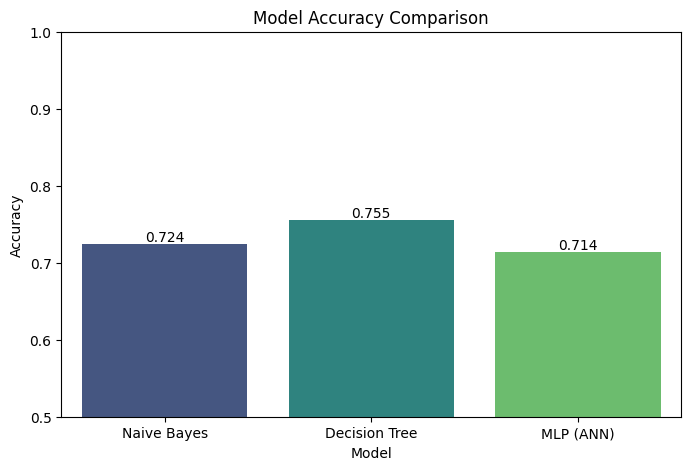

In [14]:
# --- 6. Model Comparison ---

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree', 'MLP (ANN)'],
    'Accuracy': [acc_nb, acc_dt, acc_ann]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylim(0.5, 1.0)  # Start y-axis at 0.5 to highlight differences
for index, row in results.iterrows():
    plt.text(index, row.Accuracy, f"{row.Accuracy:.3f}", color='black', ha="center", va='bottom')
plt.show()